# Brain MRI Tumor Classification (End‑to‑End)

## Introduction

**Goal**: classify brain MRI images into tumor categories (binary or multi‑class depending on your dataset folders).

- **Input**: MRI scan images
- **Output**: predicted class (e.g., `glioma`, `meningioma`, `pituitary`, `no_tumor` — or `yes/no`)

This notebook follows a standard medical imaging ML pipeline:

- Data loading + checks
- EDA
- Cleaning (optional)
- Train/val/test split
- Baseline CNN
- Transfer learning (EfficientNet)
- Evaluation + confusion matrix
- Explainability (Grad‑CAM)
- Conclusion

> Educational project only (not for clinical use).

In [ ]:
# import os
# os.environ["TF_USE_LEGACY_KERAS"] = "1"

# !pip uninstall -y tensorflow keras tf-keras tensorflow-text tensorflow-decision-forests tensorflow-hub
# !pip install tensorflow==2.19.0 tf-keras tensorflow-hub


In [ ]:
# import tensorflow as tf
# import tensorflow_hub as hub
# import tf_keras as keras
# from tf_keras import layers

In [ ]:
import os
import tensorflow as tf
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score



SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TEST_SIZE = 0.15
VAL_SIZE = 0.15

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

RUN_INTEGRITY_CHECK = False

print("TensorFlow:", tf.__version__)
print("Using GPU:", len(tf.config.list_physical_devices('GPU')) > 0)
print("TF:", tf.__version__)


TensorFlow: 2.19.0
Using GPU: True
TF: 2.19.0


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/Brain_tumor/brain_tumor_dataset")

In [ ]:
# NOTE: This was a Google Colab-only command.
# If you're running locally on Windows, set your dataset folder path in the config section instead.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
IMG_SIZE = (224, 224)
RUN_INTEGRITY_CHECK = True

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

def _is_class_folder(p):
    return p.is_dir() and not p.name.startswith(".")


Total images: 253


,count
label,
no,98
yes,155


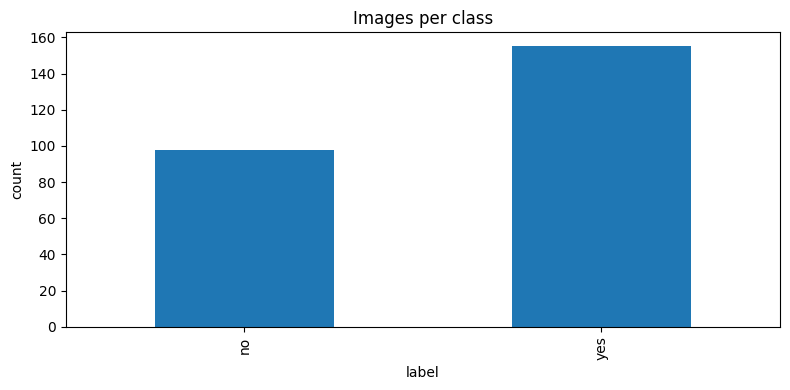

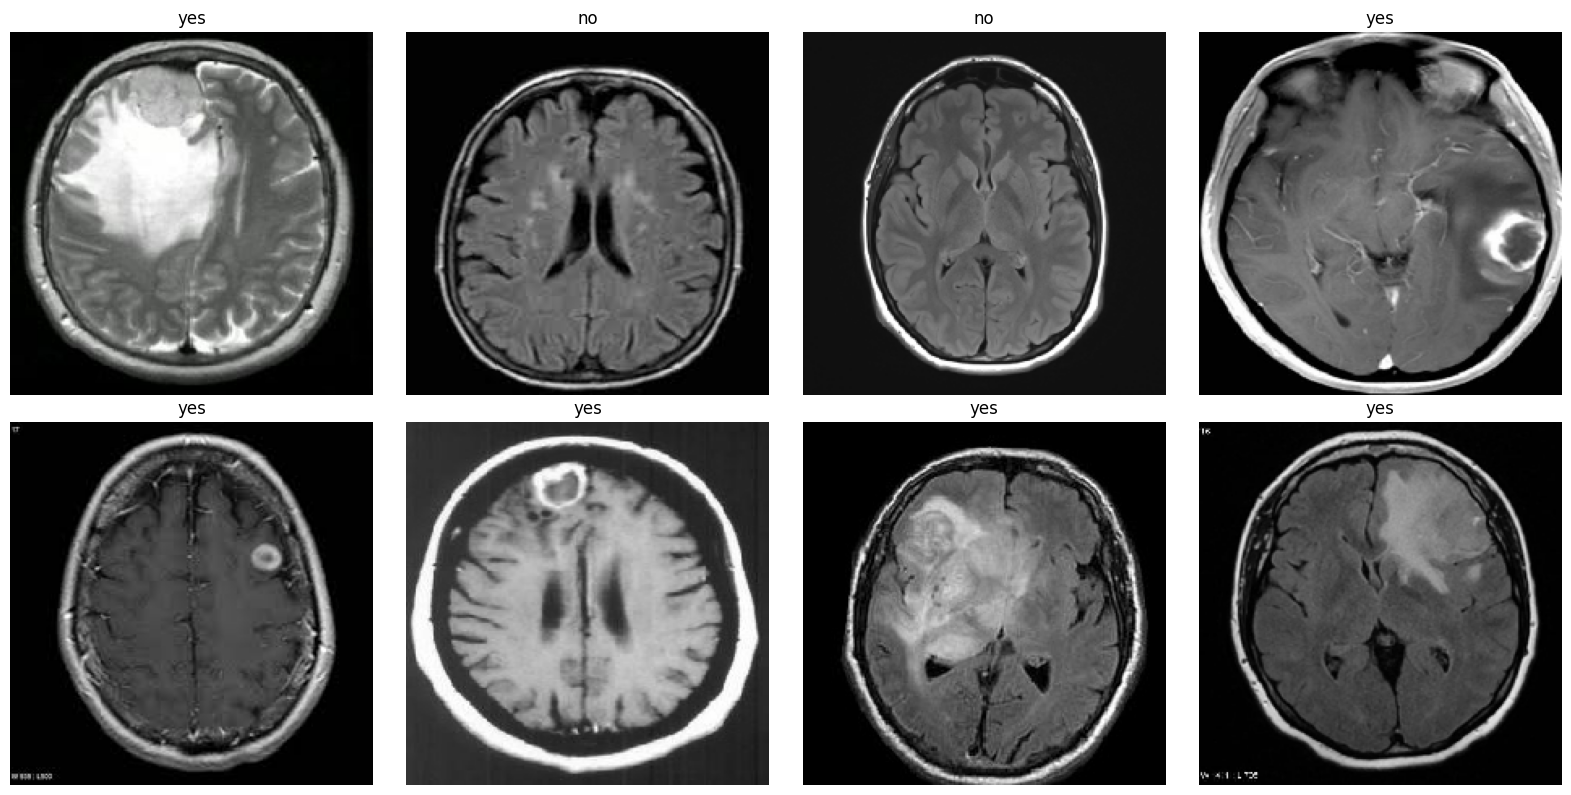

In [ ]:
# =========================
# 3) Build dataframe + EDA
# =========================

rows = []
for class_dir in sorted([d for d in DATA_DIR.iterdir() if _is_class_folder(d)]):
    for fp in class_dir.rglob("*"):
        if fp.is_file() and fp.suffix.lower() in IMAGE_EXTS:
            rows.append({"filepath": str(fp), "label": class_dir.name})

df = pd.DataFrame(rows)
print("Total images:", len(df))

assert len(df) > 0, "No images found under DATA_DIR."
assert df["filepath"].nunique() == len(df), "Duplicate filepaths found."

if RUN_INTEGRITY_CHECK:
    bad = []
    for fp in df["filepath"].tolist():
        try:
            _ = tf.keras.utils.load_img(fp)
        except Exception:
            bad.append(fp)
    if bad:
        print(f"Dropping unreadable images: {len(bad)}")
        df = df[~df["filepath"].isin(bad)].reset_index(drop=True)

label_counts = df["label"].value_counts().sort_index()
display(label_counts)

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Images per class")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Random samples
sample = df.sample(n=min(8, len(df)), random_state=SEED).reset_index(drop=True)
cols = min(4, len(sample))
rows_n = int(np.ceil(len(sample) / cols))

plt.figure(figsize=(4 * cols, 4 * rows_n))
for i, row in sample.iterrows():
    img = tf.keras.utils.load_img(row["filepath"], target_size=IMG_SIZE)
    plt.subplot(rows_n, cols, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 4) Split + tf.data pipelines
# =========================

classes = sorted(df["label"].unique().tolist())
label_to_idx = {name: i for i, name in enumerate(classes)}
idx_to_label = {i: name for name, i in label_to_idx.items()}
num_classes = len(classes)

X_paths = df["filepath"].values
y = df["label"].map(label_to_idx).astype(int).values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_paths,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

val_relative = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_relative,
    random_state=SEED,
    stratify=y_trainval,
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))
print("label_to_idx:", label_to_idx)
if num_classes == 2:
    print("Binary note: sigmoid output corresponds to class index 1 ->", classes[1])

train_counts = np.bincount(y_train, minlength=num_classes)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weight = {
    0: weights[0],
    1: weights[1]
}

print("Fixed class weights:", class_weight)

# class_weight = {i: (len(y_train) / (num_classes * c)) if c > 0 else 1.0 for i, c in enumerate(train_counts)}
# print("Class weights:", {idx_to_label[i]: round(w, 3) for i, w in class_weight.items()})


def load_and_preprocess(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    return img, label


def make_dataset(paths, labels, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(paths), 10_000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test, y_test, training=False)

Train size: 177
Val size: 38
Test size: 38
label_to_idx: {'no': 0, 'yes': 1}
Binary note: sigmoid output corresponds to class index 1 -> yes
Fixed class weights: {0: np.float64(1.3014705882352942), 1: np.float64(0.8119266055045872)}


In [ ]:
# =========================
# 5) Baseline CNN
# =========================

# data_augmentation = keras.Sequential(
#     [
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(0.08),
#         layers.RandomZoom(0.10),
#         layers.RandomContrast(0.10),
#     ],
#     name="data_augmentation",
# )


# def build_baseline_cnn(num_classes: int) -> keras.Model:
#     inputs = keras.Input(shape=(*IMG_SIZE, 3))
#     x = data_augmentation(inputs)

#     x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
#     x = layers.MaxPooling2D()(x)

#     x = layers.Dropout(0.25)(x)
#     x = layers.Flatten()(x)
#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.Dropout(0.4)(x)

#     if num_classes == 2:
#         outputs = layers.Dense(1, activation="sigmoid")(x)
#         loss = "binary_crossentropy"
#     else:
#         outputs = layers.Dense(num_classes, activation="sofmax")(x)
#         loss = "sparse_categorical_crossentropy"

#     model = keras.Model(inputs, outputs, name="baseline_cnn")
#     model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#         loss=loss,
#         metrics=["accuracy"],
#     )
#     return model

# baseline_model = build_baseline_cnn(num_classes)
# baseline_model.summary()

# callbacks = [
#     keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
#     keras.callbacks.ModelCheckpoint(
#         filepath=str(ARTIFACTS_DIR / "baseline_best.keras"),
#         monitor="val_loss",
#         save_best_only=True,
#     ),
#     keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
# ]

# EPOCHS = 15
# baseline_history = baseline_model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     class_weight=class_weight,
#     callbacks=callbacks,
# )

# baseline_probs = baseline_model.predict(test_ds)
# if num_classes == 2:
#     baseline_pred = (baseline_probs.reshape(-1) >= 0.5).astype(int)
# else:
#     baseline_pred = baseline_probs.argmax(axis=1)

# print("\nClassification report (baseline):")
# print(classification_report(y_test, baseline_pred, target_names=classes, digits=4))

# cm = confusion_matrix(y_test, baseline_pred)
# plt.figure(figsize=(6, 6))
# plt.imshow(cm, cmap="Blues")
# plt.title("Confusion matrix (baseline)")
# plt.xticks(range(num_classes), classes, rotation=45, ha="right")
# plt.yticks(range(num_classes), classes)
# plt.colorbar()
# plt.tight_layout()
# plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
    ],
    name="augmentation"   # IMPORTANT name
)

# def build_efficientnet_model(train_base=False):
#     inputs = keras.Input(shape=(*IMG_SIZE, 3))

#     x = data_augmentation(inputs)
#     x = tf.cast(x, tf.float32)
#     x = keras.applications.efficientnet.preprocess_input(x)

#     backbone = keras.applications.EfficientNetB0(
#         include_top=False,
#         weights="imagenet",          # ✅ use ImageNet
#         input_shape=(*IMG_SIZE, 3),
#     )
#     backbone.trainable = train_base

#     x = backbone(x, training=train_base)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dropout(0.3)(x)

#     outputs = layers.Dense(1, activation="sigmoid")(x)

#     model = keras.Model(inputs, outputs, name="tumor_effnetb0_bin")
#     model.compile(
#         optimizer=keras.optimizers.Adam(1e-4),
#         loss="binary_crossentropy",
#         metrics=["accuracy", keras.metrics.AUC(name="auc")]
#     )
#     return model

def build_efficientnet_model(train_base=False):
    inputs = keras.Input(shape=(*IMG_SIZE, 3))  # float32 by default

    x = data_augmentation(inputs)
    x = keras.applications.efficientnet.preprocess_input(x)

    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
    )
    backbone.trainable = train_base

    x = backbone(x, training=train_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="tumor_effnetb0_bin")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model


adv_model = build_efficientnet_model(train_base=False)
adv_model.summary()


Model: "tumor_effnetb0_bin"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 789ms/step - accuracy: 0.4777 - auc: 0.4372 - loss: 0.8006 - val_accuracy: 0.6316 - val_auc: 0.6855 - val_loss: 0.6385 - learning_rate: 1.0000e-04
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.5903 - auc: 0.5064 - loss: 0.7248 - val_accuracy: 0.6316 - val_auc: 0.7188 - val_loss: 0.6336 - learning_rate: 1.0000e-04
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.5771 - auc: 0.4813 - loss: 0.7150 - val_accuracy: 0.6316 - val_auc: 0.7478 - val_loss: 0.6291 - learning_rate: 1.0000e-04
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.5743 - auc: 0.4792 - loss: 0.7235 - val_accuracy: 0.6579 - val_auc: 0.7768 - val_loss: 0.6247 - learning_rate: 1.0000e-04
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.5598 - auc: 0.4719 - loss: 0.7153 - val_accuracy: 0.6579 - val_auc: 0.8000 - val_loss: 0.6210 - learning_rate: 1.0000e-04
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.6128 

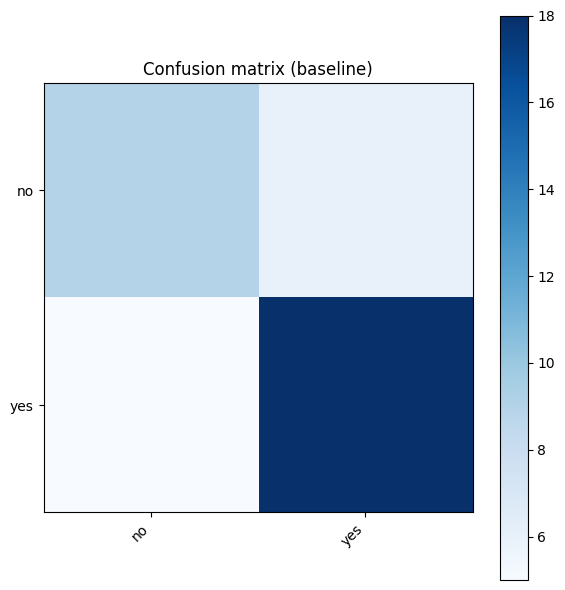

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "baseline_best.keras"),
        monitor="val_loss",
        save_best_only=True,
    ),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

EPOCHS = 15
baseline_history = adv_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

baseline_probs = adv_model.predict(test_ds)
if num_classes == 2:
    baseline_pred = (baseline_probs.reshape(-1) >= 0.5).astype(int)
else:
    baseline_pred = baseline_probs.argmax(axis=1)

print("\nClassification report (baseline):")
print(classification_report(y_test, baseline_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_test, baseline_pred)
plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix (baseline)")
plt.xticks(range(num_classes), classes, rotation=45, ha="right")
plt.yticks(range(num_classes), classes)
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
df['label'].value_counts()

,count
label,
yes,155
no,98


In [ ]:
# 1) Get the backbone
base = adv_model.get_layer("efficientnetb0")   # name from your model summary

# 2) Unfreeze it
base.trainable = True

# 3) (Recommended) Freeze BatchNorm layers (stability on small dataset)
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# 4) (Optional but recommended) Only fine-tune last N layers
N = 50
for layer in base.layers[:-N]:
    layer.trainable = False

# 5) Re-compile after changing trainable flags
LR_STAGE2 = 1e-5
adv_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_STAGE2),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print("✅ Fine-tuning setup done")


✅ Fine-tuning setup done


In [ ]:
EPOCHS_STAGE2 = 10
hist_stage2 = adv_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weight
)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 700ms/step - accuracy: 0.5847 - auc: 0.6631 - loss: 0.6469 - val_accuracy: 0.8421 - val_auc: 0.9319 - val_loss: 0.5593
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6418 - auc: 0.7018 - loss: 0.6304 - val_accuracy: 0.8684 - val_auc: 0.9435 - val_loss: 0.5436
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7634 - auc: 0.7768 - loss: 0.6081 - val_accuracy: 0.8684 - val_auc: 0.9493 - val_loss: 0.5299
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7343 - auc: 0.7875 - loss: 0.5979 - val_accuracy: 0.8684 - val_auc: 0.9507 - val_loss: 0.5153
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7034 - auc: 0.7617 - loss: 0.6112 - val_accuracy: 0.8421 - val_auc: 0.9522 - val_loss: 0.5032
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7276 - auc: 0.7757 - loss: 0.5902 - val_accuracy: 0.8158 - val_auc: 0.9551 - val_loss: 0.4913
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accur

In [ ]:
adv_model.save("adv_final_tfhub.keras")
print("Saved final model ✅")


Saved final model ✅


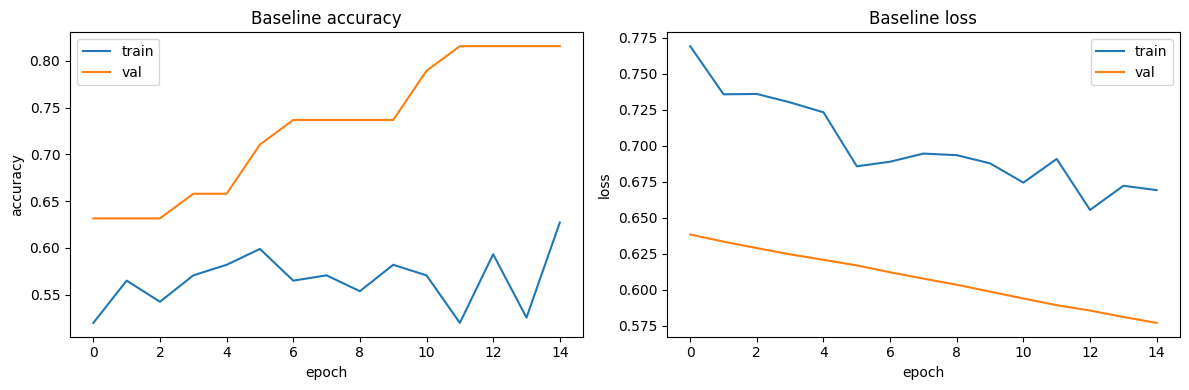

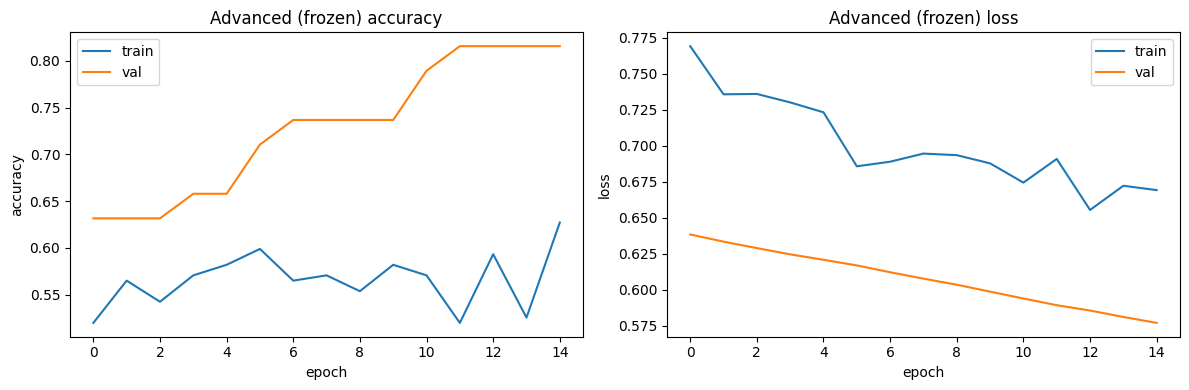

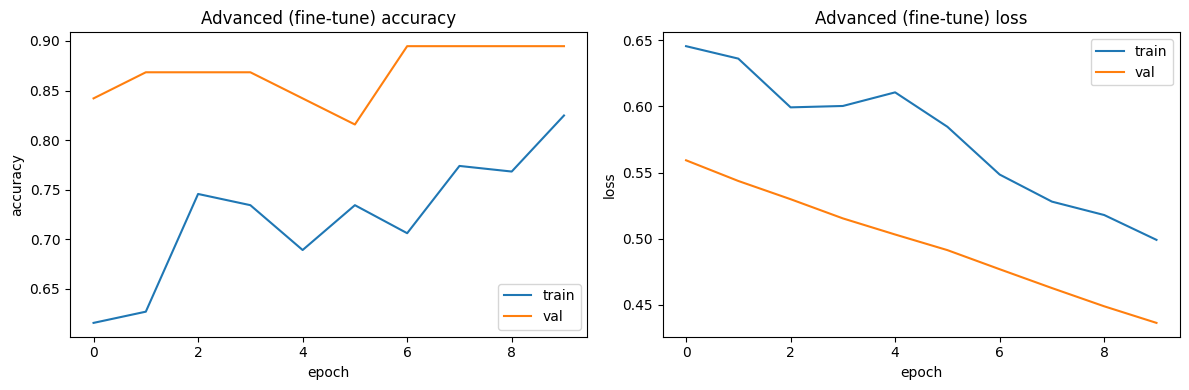

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step

Classification report (advanced):
              precision    recall  f1-score   support

          no     0.8125    0.8667    0.8387        15
         yes     0.9091    0.8696    0.8889        23

    accuracy                         0.8684        38
   macro avg     0.8608    0.8681    0.8638        38
weighted avg     0.8710    0.8684    0.8691        38



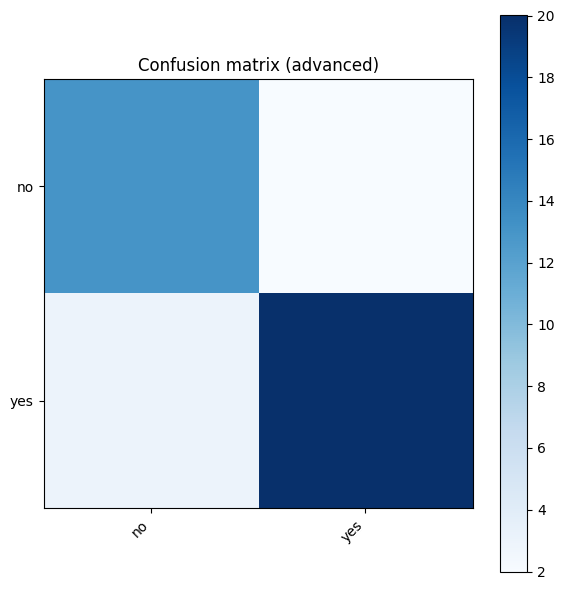

,model,test_accuracy,test_f1
0,baseline_cnn,0.710526,0.765957
1,efficientnetb0,0.868421,0.888889


In [ ]:
# =========================
# 7) Advanced evaluation + comparison
# =========================

def plot_history(hist, title_prefix: str):
    h = hist.history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(h.get("accuracy", []), label="train")
    plt.plot(h.get("val_accuracy", []), label="val")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h.get("loss", []), label="train")
    plt.plot(h.get("val_loss", []), label="val")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline")
plot_history(baseline_history, "Advanced (frozen)")
plot_history(hist_stage2, "Advanced (fine-tune)")

adv_probs = adv_model.predict(test_ds)
if num_classes == 2:
    adv_pred = (adv_probs.reshape(-1) >= 0.5).astype(int)
else:
    adv_pred = adv_probs.argmax(axis=1)

print("\nClassification report (advanced):")
print(classification_report(y_test, adv_pred, target_names=classes, digits=4))

cm_adv = confusion_matrix(y_test, adv_pred)
plt.figure(figsize=(6, 6))
plt.imshow(cm_adv, cmap="Blues")
plt.title("Confusion matrix (advanced)")
plt.xticks(range(num_classes), classes, rotation=45, ha="right")
plt.yticks(range(num_classes), classes)
plt.colorbar()
plt.tight_layout()
plt.show()

baseline_acc = accuracy_score(y_test, baseline_pred)
adv_acc = accuracy_score(y_test, adv_pred)

baseline_f1 = f1_score(y_test, baseline_pred, average="binary" if num_classes == 2 else "macro")
adv_f1 = f1_score(y_test, adv_pred, average="binary" if num_classes == 2 else "macro")

pd.DataFrame(
    [
        {"model": "baseline_cnn", "test_accuracy": baseline_acc, "test_f1": baseline_f1},
        {"model": "efficientnetb0", "test_accuracy": adv_acc, "test_f1": adv_f1},
    ]
)

In [ ]:
# Duplicate evaluation cell removed.
# Use the earlier evaluation cell (cell 9).


In [ ]:
print("adv_model.inputs:", adv_model.inputs)
print("adv_model.input:", adv_model.input)


adv_model.inputs: [<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]
adv_model.input: <KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>


In [ ]:
adv_model.summary()


Model: "tumor_effnetb0_bin"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,070,792 (34.60 MB)

 Trainable params: 2,509,969 (9.57 MB)

 Non-trainable params: 1,540,883 (5.88 MB)

 Optimizer params: 5,019,940 (19.15 MB)

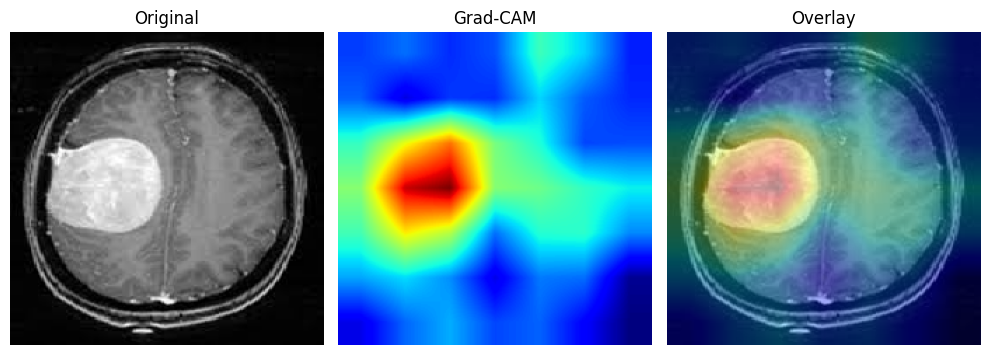

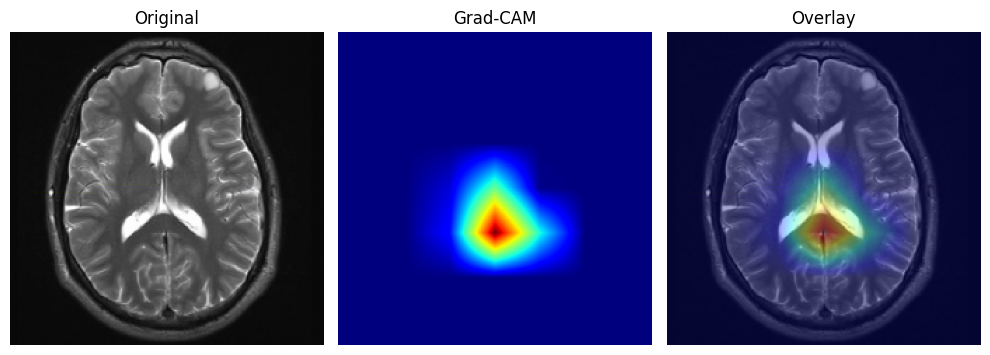

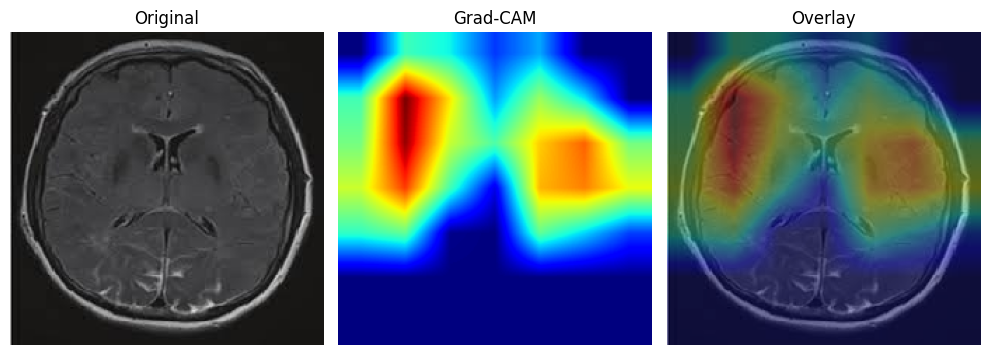

In [ ]:
# ================================
# Grad-CAM for EfficientNet Model
# ================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras


# ----------------------------
# Find last Conv2D layer
# ----------------------------
def find_last_conv_layer(model):
    backbone = model.get_layer("efficientnetb0")

    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

    raise ValueError("❌ No Conv2D layer found in EfficientNet backbone.")


# ----------------------------
# Grad-CAM heatmap
# ----------------------------
def make_gradcam_heatmap(img_batch, model):

    aug = model.get_layer("augmentation")
    backbone = model.get_layer("efficientnetb0")
    drop = model.get_layer("dropout")
    head = model.get_layer("dense")

    last_conv_name = find_last_conv_layer(model)
    last_conv = backbone.get_layer(last_conv_name)

    # Build model that outputs conv + prediction
    backbone_cam = keras.Model(
        inputs=backbone.input,
        outputs=[last_conv.output, backbone.output]
    )

    with tf.GradientTape() as tape:

        # Forward pass exactly like training
        x = aug(model.input)
        conv_out, feats = backbone_cam(x, training=False)
        preds = head(drop(feats, training=False), training=False)

        full_model = keras.Model(model.input, [conv_out, preds])
        conv_out, preds = full_model(img_batch, training=False)

        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


# ----------------------------
# Display on image
# ----------------------------
def show_gradcam_on_image(img_path, model, alpha=0.35):

    img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_arr = keras.utils.img_to_array(img).astype("float32")

    img_batch = np.expand_dims(img_arr, axis=0)

    heatmap = make_gradcam_heatmap(img_batch, model)

    heatmap_resized = tf.image.resize(
        heatmap[..., None], IMG_SIZE
    ).numpy().squeeze()

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(heatmap_resized, cmap="jet", alpha=alpha)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ----------------------------
# Run on random test samples
# ----------------------------
for idx in np.random.RandomState(SEED).choice(
    len(X_test), size=min(3, len(X_test)), replace=False
):
    show_gradcam_on_image(str(X_test[idx]), adv_model)


Misclassified examples: 5


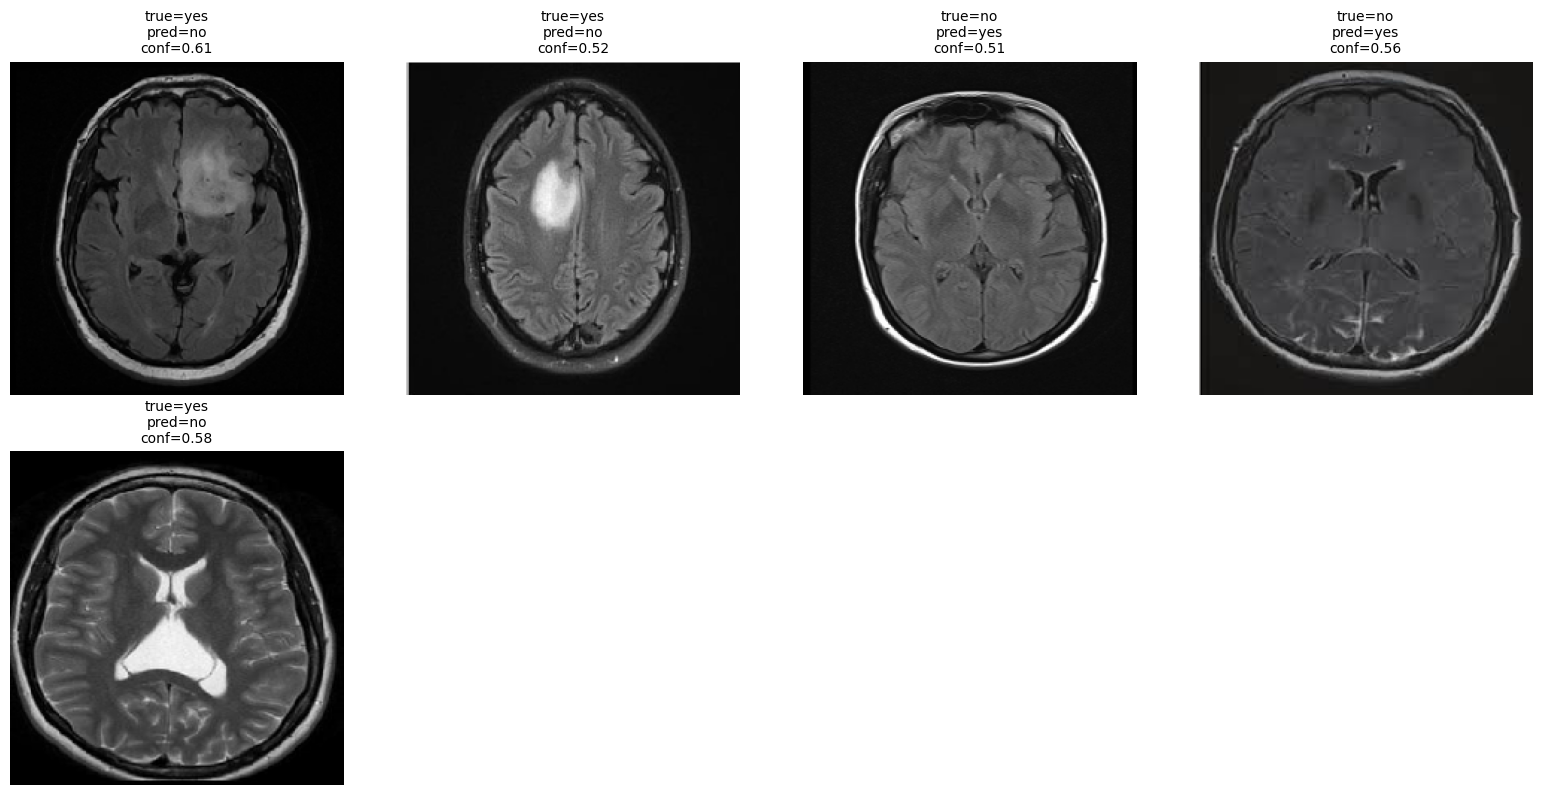

In [ ]:
# =========================
# 9) Error analysis: show misclassified examples
# =========================

wrong_idx = np.where(adv_pred != y_test)[0]
print("Misclassified examples:", len(wrong_idx))

if len(wrong_idx) > 0:
    show_n = min(8, len(wrong_idx))
    pick = np.random.RandomState(SEED).choice(wrong_idx, size=show_n, replace=False)

    cols = 4
    rows_n = int(np.ceil(show_n / cols))
    plt.figure(figsize=(4 * cols, 4 * rows_n))

    for i, wi in enumerate(pick):
        fp = str(X_test[wi])
        true_i = int(y_test[wi])
        pred_i = int(adv_pred[wi])

        img = keras.utils.load_img(fp, target_size=IMG_SIZE)

        if num_classes == 2:
            p1 = float(adv_probs[wi].reshape(-1)[0])
            pred_prob = p1 if pred_i == 1 else (1.0 - p1)
        else:
            pred_prob = float(adv_probs[wi, pred_i])

        plt.subplot(rows_n, cols, i + 1)
        plt.imshow(img)
        plt.title(
            f"true={classes[true_i]}\npred={classes[pred_i]}\nconf={pred_prob:.2f}",
            fontsize=10,
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# =========================
# 10) Save label mapping + inference helper
# =========================

import json

with open(ARTIFACTS_DIR / "label_to_idx.json", "w", encoding="utf-8") as f:
    json.dump(label_to_idx, f, indent=2)

print("Saved label map:", ARTIFACTS_DIR / "label_to_idx.json")


def predict_image(model: keras.Model, img_path: str):
    img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    x = keras.utils.img_to_array(img).astype("float32") / 255.0
    x = np.expand_dims(x, axis=0)

    probs = model.predict(x, verbose=0)
    if num_classes == 2:
        p1 = float(probs.reshape(-1)[0])
        pred_idx = 1 if p1 >= 0.5 else 0
        probs_vec = np.array([1.0 - p1, p1])
    else:
        probs_vec = probs.reshape(-1)
        pred_idx = int(np.argmax(probs_vec))

    return {
        "pred_label": classes[pred_idx],
        "pred_idx": pred_idx,
        "probs": probs_vec,
    }

example_fp = str(X_test[np.random.RandomState(SEED).randint(0, len(X_test))])
res = predict_image(adv_model, example_fp)
print("Example:", example_fp)
print("Prediction:", res["pred_label"])
print("Probabilities:", {classes[i]: float(res["probs"][i]) for i in range(num_classes)})

Saved label map: artifacts/label_to_idx.json


Example: /content/drive/MyDrive/Brain_tumor/brain_tumor_dataset/no/19 no.jpg
Prediction: no
Probabilities: {'no': 0.5297397971153259, 'yes': 0.4702602028846741}


## Conclusion

You now have a complete runnable brain MRI classification notebook:

- Folder‑based dataset ingestion (works for binary or multi‑class)
- EDA + optional integrity checks
- Baseline CNN + EfficientNet transfer learning
- Evaluation (classification report + confusion matrix)
- Grad‑CAM explainability

### Next steps

- Try additional backbones (ResNet50V2 / DenseNet121).
- Tune augmentation and learning rate schedules.
- Ensure patient‑level splitting if patient metadata exists.
- Add calibration + uncertainty (important for medical AI).